# Introduction to utilising crowdsourced data

CMT224: Social Computing

<br>
<br>

## Case Study

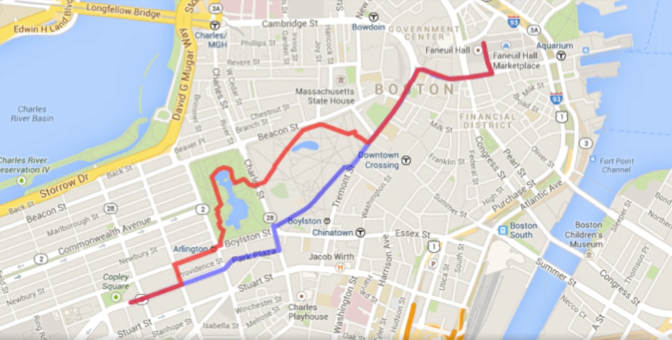 -- Daniele Quercia et al, 2015

## Datasets: Fictional Road Network and "Crowdsourced" Emotive Annotations

> **Road Network**
>
>Alongside this notebook is a dataset file "roads.gml" which contains a network representation of a *fictional* town/city for demonstration purposes. See the Twitch notebook from earlier sessions for more information on the GML file format.
> The road network was generated from OpenStreetMap data using the pyrosm library in order to be representative of a real road network, rather than a random network or a social network, etc. 
>
>For those interested, the data for part of Helsinki was used as the initial basis for the network and then simplified and pruned down to a manageable size to explore as an exercise. 
>> **Optional extra if of interest:** Pyrosm library documentation https://pyrosm.readthedocs.io/en/latest/index.html
>
> Therefore, the annotations and scoring of roads used in the remainder of this notebook should not be considered as representative in any way of the original, real-world road data that was used as the basis to create the network.


> **"Crowdsourced" Emotive Annotations**
>
> Alongside this notebook is a second dataset file "annotations.csv", which contains the output from a ***simulated*** crowdsourcing task using 6 fictional annotators with identifiers A to F. In this simulated data, assume that:
> - Each annotator provided an annotation for every pair of roads in the network: 569,778 each. (This may not always be the case in other datasets, more on this later).
> - For each pair of roads, each annotator was presented with side-by-side Google Street View (or similar) images of the roads and asked to choose which one, A or B, made them feel "calmer".
> - The choice of either Road A or Road B is recorded as well as the time taken to make the choice in seconds.

- We will undertake a task that is inspired from the Happy Maps project discussed in earlier weeks:

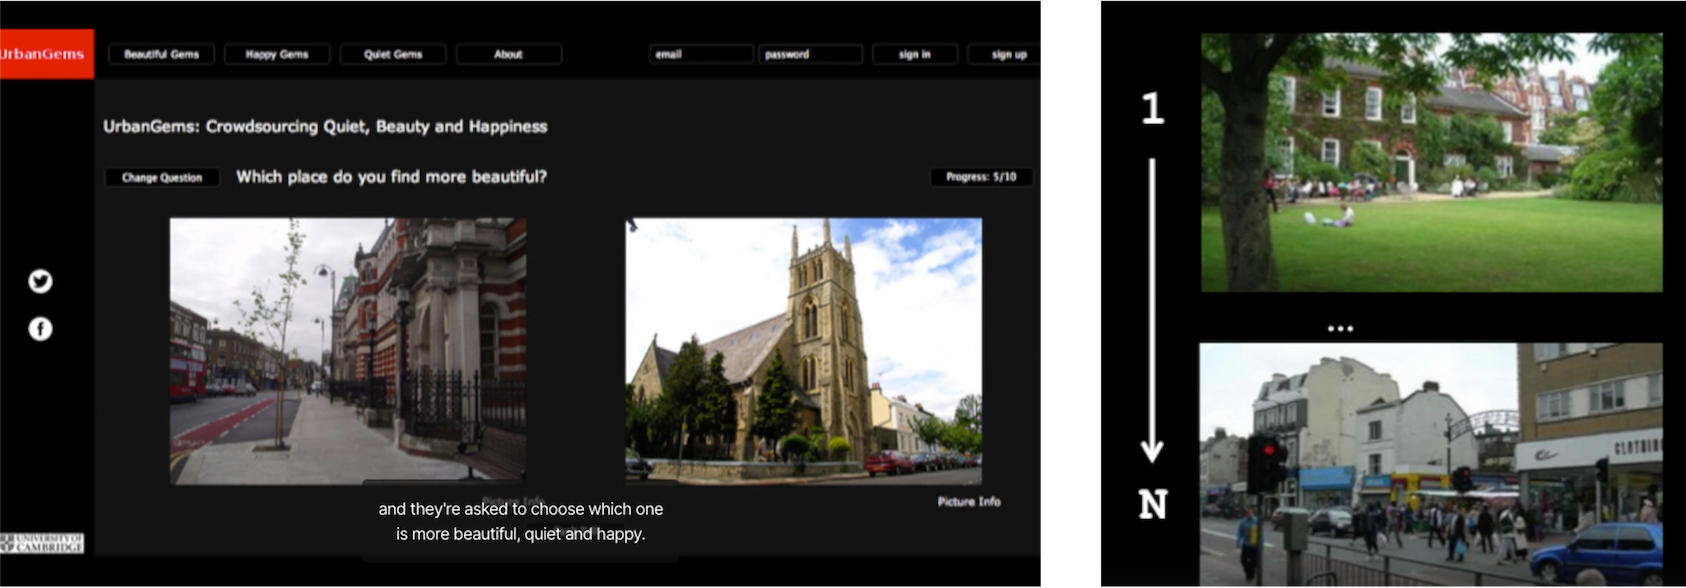  -- Daniele Quercia et al, 2015

- Whereby we will analyse aggregated data from an annotation task to score and rank roads in our fictional road network and explore how this may effect the routes calculated from one part of our fictional city to another.

- Along the way we will explore different considerations when utilising "crowdsourced" data including inter-annotator agreement and other data quality issues that can arise. We will also explore the concept of centrality from network science in examining the effects of road scores on the routes calculated.




---

<font color="#F4A460">This exercise assumes a Python 3 ipykernel environment. </font>

<font color="#F4A460"> If you are not running a virtual environment, run the cell below. Or if you are running a virtual environment, install networkx, matplotlib, etc, and jupyter/ipykernel in the virtual environment instead. </font>


In [1]:
%pip install networkx scipy pandas numpy krippendorff

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


> **Extra**: More information on the krippendorff package can be found here: https://pypi.org/project/krippendorff/.
> Its use is discussed later in the notebook.

---
<br>

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import itertools
import csv
import matplotlib.colors as mcolors

<br>
<br>

## 1. Examining the datasets

### Road network

In the road network described in the previous section, road junctions in the network are represented as nodes and the roads between them are represented as the network's edges. 

For simplicity here, we can assume:
 - There are no one-way roads in the network, which results in an undirected network.
 - Routes (or paths across the network) will therefore be road junction to road junction (node to node), rather than a particular place on a road to another place on a road.
 - Each edge represents the same length in the physical world, the same speed limits, traffic conditions, etc.

<br>

Lets explore the network data file using NetworkX:

In [3]:
# The network is contained in a .gml file - Refer back to the Week 2 Twitch notebook for more information on the GML format

G = nx.read_gml("roads.gml")

In [4]:
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Number of nodes: 940
Number of edges: 1068


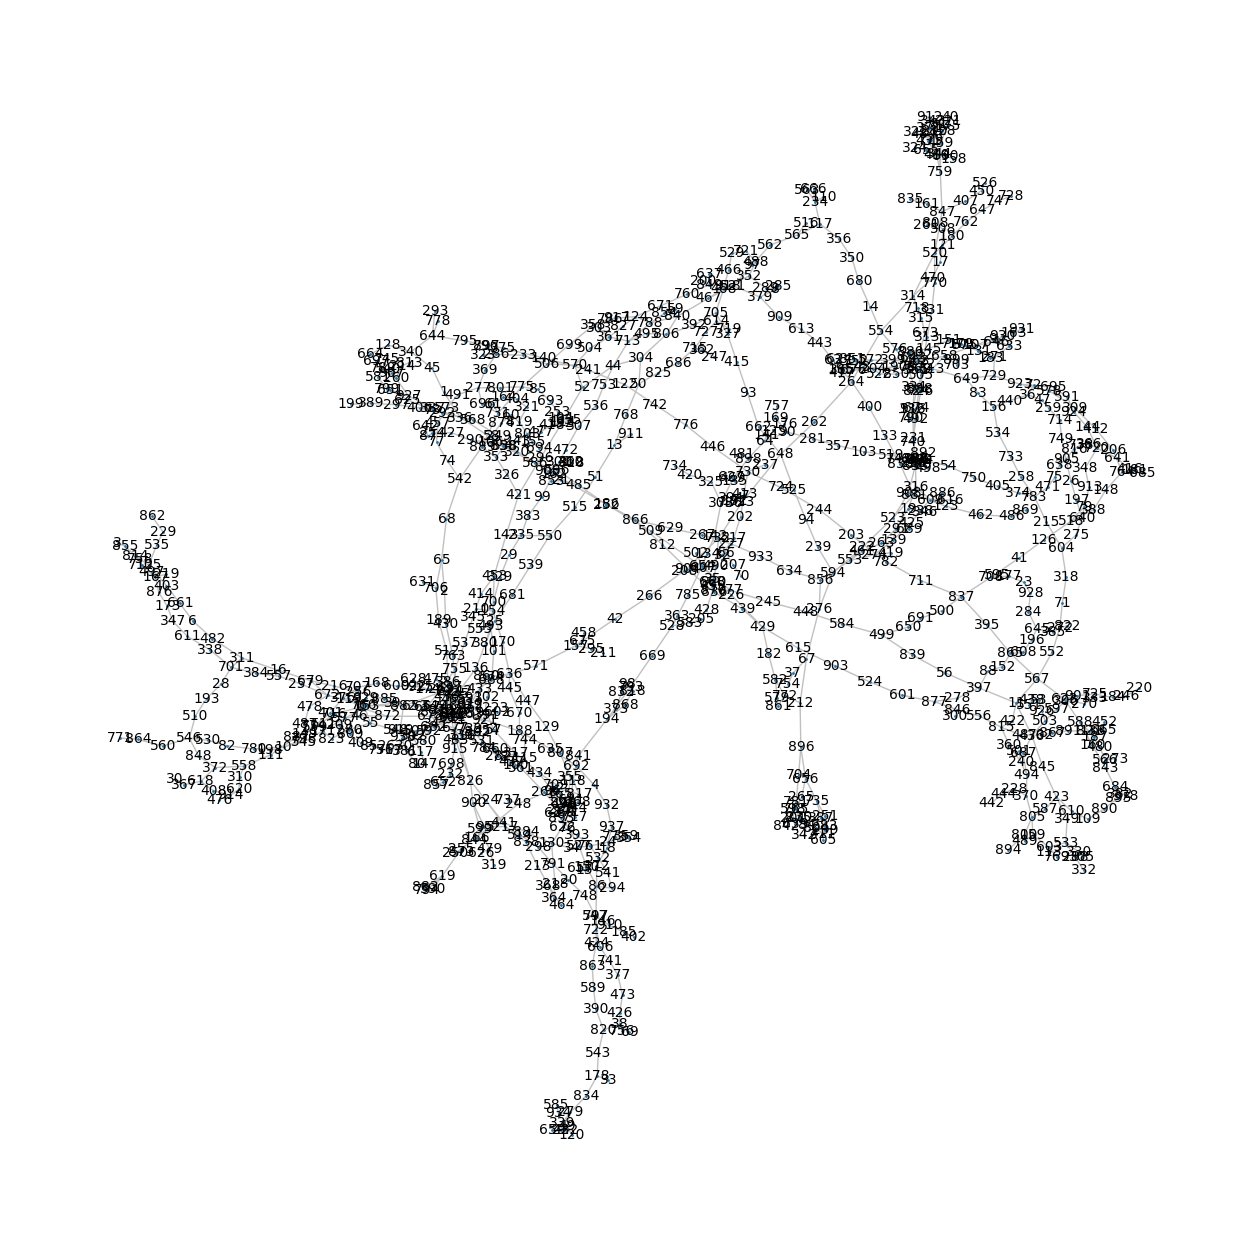

In [5]:
# Visualise the network - Refer to the Week 1 notebook for more information on visualising networks with NetworkX

fig3, ax3 = plt.subplots(figsize=(16,16))
nx.draw(G, 
        pos = nx.spring_layout(G, seed=100, k=0.01), # Use a spring layout with a fixed random seed to preserve node positions each time this cell is ran.
        ax = ax3, 
        with_labels = True, # Draw the node ids (random integers) on top of the network visualisation
        node_size = 1,       # Set the node circle size to small so that we can focus on observing the node ids
        edge_color = "silver",
        font_size = 10
       )
plt.show()

<br>
<br>

### "Crowdsourced" Emotive Annotations

Lets take a look at a sample of the annotations dataset:

The dataset contains roads that are represented using two random integer IDs joined by a hyphen/dash. These integers represent unique indentifiers for junctions in our fictional city. e.g., road 38-756 represents the road between junction 38 and 756.

In [6]:
# The Pandas library is used here for formatting aesthetics in the cell output below only.
df = pd.read_csv('annotations.csv')
print(df)

        annotator   road_A   road_B chosen_road  time_taken
0               A   38-756  190-399      38-756          15
1               A  358-786  503-926     503-926          19
2               A   53-926  250-255      53-926          16
3               A   28-701  255-619     255-619          19
4               A   576-78   294-86      294-86          16
...           ...      ...      ...         ...         ...
3418663         F   17-470  723-732      17-470          17
3418664         F   542-74  788-840      542-74          16
3418665         F   13-911  477-803      13-911          13
3418666         F   150-86  263-461     263-461          18
3418667         F   542-74  637-849      542-74          25

[3418668 rows x 5 columns]


<br>
<br>

---

<br>
<br>

## 2. Examining and scrutinising the annotation data

In the annotations dataset we have multiple annotations for each road - one from each annotator. One aspect we can look to explore initially is the extent to which the annotators agreed or disagreed with each other.

### Considering annotator agreement (or lack of)

We will begin by creating a nested Python dictionary to store the choices made for each annotator in a more convenient way for accessing and comparing them. This is an example data structure of several possibilities and use of additional libraries such as pandas could reduce the implementation if desired.

In [7]:
annotation_dictionary = {}         # Create a Python dictionary where keys will be annotator ids and values will be dictionaries of edge pairs and the choices made between them.

with open('annotations.csv', 'r') as file:
    reader = csv.reader(file)
    next(reader, None)  # skip the header
    
    for row in reader:               # For each annotation across all annotators, extract out the annotator id, the edge pair being chosen between, and the choice made.
        annotator = row[0]
        edge_choice_A = row[1]
        edge_choice_B = row[2]
        chosen_edge = row[3]
        
        choice = "A" if chosen_edge == edge_choice_A else "B"
        
        if annotator not in annotation_dictionary:                          # If the annotator doesn't exist in the annotation_dictionary yet, add them.
            annotation_dictionary[annotator] = {}
        
        annotation_dictionary[annotator][edge_choice_A+"+"+edge_choice_B] = choice
        

In [8]:
# Create lists of fixed orders for annotators and annotations in case notebook is ran on Python <3.7 where dictionary order is unpredictable.

annotator_order = list(annotation_dictionary.keys())
annotation_order = list(annotation_dictionary[annotator_order[0]].keys())

<br>

A first question to explore could simply be:

**How many road choices did the annotators agree or disagree on?**

In [9]:
number_of_roads_with_full_agreement = 0
number_of_roads_with_disagreement = 0

for road_choice in annotation_order:
    
    annotations = [annotation_dictionary[annotator][road_choice] for annotator in annotator_order]  # Create a list of Road Choices made by each annotator, e.g. ["A", "A", "B", "B", "A", "A"]
    
    if "A" in annotations and "B" in annotations:                                                   # If at least one "A" and "B" exist in the list then there must have been at least some disagreement
        number_of_roads_with_disagreement += 1
    else:                                                                                           # Otherwise the annotators all chose either road choice "A" or "B"
        number_of_roads_with_full_agreement += 1

print(f"Number of road pairs where all annotators agreed: {number_of_roads_with_full_agreement}")
print(f"Number of road pairs with at least some disagreement: {number_of_roads_with_disagreement}")

Number of road pairs where all annotators agreed: 237645
Number of road pairs with at least some disagreement: 332133


<br>
From this, we can see that the annotators cannot agree which road is better for the majority of pairs of roads. 

However, this doesn't tell us the extent of disagreement, i.e., is it just one annotator or many?

<br>
<br>

#### Inter-annotator (Inter-rater) agreement

To help quantify the extent to which annotators agree or disagree across a set of annotations, we can adopt an inter-annotator agreement measure that calculates a score which is indicative of the strength of agreement, disagreement, or whether there is weak evidence either way. 

Several inter-annotator agreements have been proposed and each have their own requirements in which they can be used. Examples include but are not limited to:

- *Cohen's Kappa*: Limited to two annotators annotating each and every item;
> Extra: https://www.statisticshowto.com/cohens-kappa-statistic/
- *Fleiss' Kappa*: Flexible to any number of annotators, and not every annotator needs to annotate every time;
> Extra: https://www.statisticshowto.com/fleiss-kappa/
- *Krippendorff's Alpha*: Similar flexibility to Fleiss' Kappa. Flexible to different types of data (nominal, ordinal, interval, ratio)
> Extra: https://www.statisticshowto.com/krippendorffs-alpha/

Here we will use krippendorff alpha, but Fleiss' Kappa would also be appropriate. The "krippendorff" Python library provides an implementation to handle the calculation of the inter-annotator agreement scores:
https://pypi.org/project/krippendorff/.

In [34]:
import krippendorff

The krippendorff library's "alpha" method call requires a list of annotation lists and an optional parameter that describes the type of data. 

Here our data is nominal (independent categories with no order).

<br>
<br>

**A brief sample inspection of annotator dis(agreement):**

In [38]:
# Create a nested Python list version of the annotation dictionary ready for use with the krippendorff library - i.e., a list of 7 lists, with each containing a list of 569,778 annotations.
# Using the fixed list of annotator and annotation orders for safety in Python <3.7 where dictionary order is unpredictable.
# The implementation below expanded for readability and could be reduced.

all_annotation_data = []
for annotator in annotator_order:
    
    annotations_for_specific_annotator = []
    for annotation in annotation_order:
        annotations_for_specific_annotator.append(annotation_dictionary[annotator][annotation])
        
    all_annotation_data.append(annotations_for_specific_annotator)
        

In [39]:
for i, annotator in enumerate(annotator_order):
    print(f"Annotator {annotator} "
          f"sample annotations = {all_annotation_data[i][30:50]} "
         )

Annotator A sample annotations = ['A', 'A', 'A', 'B', 'A', 'A', 'A', 'B', 'B', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'A', 'A', 'B'] 
Annotator B sample annotations = ['A', 'A', 'A', 'B', 'A', 'A', 'A', 'B', 'B', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'A', 'A', 'B'] 
Annotator C sample annotations = ['A', 'A', 'A', 'B', 'A', 'A', 'A', 'B', 'B', 'A', 'A', 'A', 'B', 'B', 'B', 'A', 'B', 'A', 'A', 'B'] 
Annotator D sample annotations = ['A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A'] 
Annotator E sample annotations = ['A', 'A', 'A', 'B', 'A', 'B', 'A', 'B', 'B', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'A', 'A', 'B'] 
Annotator F sample annotations = ['B', 'A', 'A', 'B', 'A', 'B', 'A', 'B', 'B', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'A', 'B', 'B'] 


<br>
<br>

Using this structure for the data we can call the krippendorff library's alpha method.

The value returned will be between -1 and +1 where -1 indicates strong disagreement, +1 indicates strong agreement and 0 weak evidence either way.

For reasonable confidence in agreement between annotators, Krippendorff has previously recommended that a score of >=0.800 is desirable and where tentative conclusions are  acceptable, >= 667.  
> - Klaus Krippendorff (2004). Content analysis: An introduction to its methodology.

In [41]:
alpha = krippendorff.alpha(
    all_annotation_data, 
    level_of_measurement="nominal"
)

print(f"alpha = {alpha:.2f}")

alpha = 0.56


<br>

The results highlight that there is some agreement, however the strength of this is reasonably low. This is reflective of the "How many road choices did the annotators agree or disagree on?" seen in previous cells.

So what does this mean? It *could* mean that:

- the classification of perceived "calmness" is too subjective to result in majority agreement between humans;

- that more annotators are needed to reach a confident, general consensus;

- one or more annotators have provided notably different annotations than the majority that drastically effects the alpha score. 

<br>
<br>

To investigate the later, we can also calculate alpha scores on a pairwise basis for each pair of annotators:


In [43]:
annotator_pairs = itertools.combinations(annotator_order, 2)

for pair in annotator_pairs:
    
    print(f"Annotator {pair[0]} and {pair[1]}: "
          f"alpha = {krippendorff.alpha([all_annotation_data[annotator_order.index(pair[0])], all_annotation_data[annotator_order.index(pair[1])]], level_of_measurement='nominal'):.3f} "
         )


Annotator A and B: alpha = 0.912 
Annotator A and C: alpha = 0.913 
Annotator A and D: alpha = -0.333 
Annotator A and E: alpha = 0.914 
Annotator A and F: alpha = 0.912 
Annotator B and C: alpha = 0.840 
Annotator B and D: alpha = -0.296 
Annotator B and E: alpha = 0.827 
Annotator B and F: alpha = 0.825 
Annotator C and D: alpha = -0.296 
Annotator C and E: alpha = 0.827 
Annotator C and F: alpha = 0.826 
Annotator D and E: alpha = -0.373 
Annotator D and F: alpha = -0.373 
Annotator E and F: alpha = 0.840 


<br>

Some observations from this are:

- Here we can see generally strong agreement between most pairs (i.e., >=0.8)

- However, there is a notable pattern in disagreement between annotator D and each other annotator.

If we omit D's annotators from the interannotator agreement calculation, we can see generally strong agreement in comparison to considering all annotators together:

In [47]:
trimmed_annotation_data = [all_annotation_data[i] for i, annotator in enumerate(annotator_order) if annotator != "D"] # Create a new nested dictionary without annotator D's annotations

alpha = krippendorff.alpha(                  # Re-calculate the alpha value
            trimmed_annotation_data,  
            level_of_measurement="nominal"
)

print(f"alpha = {alpha:.2f}")


alpha = 0.86


<br>

**Decision made?**

- Caution should be taken in assuming that the disagreement between an annotator and others means that the quality of the data of that annotator is "bad".

- It may be that annotator D highlights that the labelling task is more subjective than anticipated and this may then motivate collecting data from more annotators.

- However, there may be other characteristics in the data that can shed further light on this.

<br>

### Considering additional data quality characteristics

We can also examine other aspects of the annotation data, such as the time taken to do each annotation (where this is available in the data). In the dataset used here, the fifth column details the time taken for each annotation in seconds.

In [50]:
annotation_times = {}             # Create a Python dictionary where keys are annotator ids and the values are lists of times taken for each annotation by each annotator

with open('annotations.csv', 'r') as file:
    reader = csv.reader(file)
    next(reader, None)  # skip the header
    
    for row in reader:                                   # For each annotation across all annotators, extract out the annotator id and the time taken (annotation time).
        annotator = row[0]
        
        if annotator not in annotation_times:            # If the annotator doesn't exist in the annotation_dictionary yet, add them.
            annotation_times[annotator] = []
            
        annotation_times[annotator].append(int(row[4]))
        

<br>

Descriptive statistics of the time taken can provide an initial indication of any notable differences or anomalies in behaviour between annotators.

In [52]:
for annotator, times in annotation_times.items():
    print(f"Annotator {annotator}:  "
          f"M={np.mean(times):.2f} " 
          f"SD={np.std(times):.2f}"
         )


Annotator A:  M=17.00 SD=1.41
Annotator B:  M=17.00 SD=3.74
Annotator C:  M=14.50 SD=2.87
Annotator D:  M=1.50 SD=0.50
Annotator E:  M=14.50 SD=2.29
Annotator F:  M=18.99 SD=3.74


<br>

Some observations:

- Here we can see that annotator D could be considered to be notably (and perhaps suspicously) quicker at providing annotations in comparison to the other annotators. However, an appropriate statistical test would provide stronger evidence to this claim.
- This provides an additional basis to consider whether the annotations provided by annotator D are of sufficient quality to be considered. Nevertheless, caution should be taken in making assumptions about how long annotations *should* typically take to make.
- Furthermore, the very short annotation time could prompt for further investigations into whether there are any underlying patterns in the annotation choices (go back to "**A brief sample inspection of annotator dis(agreement):**" cell above and observe annotator D's annotations).

>**Extra**: Extend or re-run the cost calculations in Section 2 with annotator D's annotations removed and observe the differences that this makes to the edge cost calculations.

<br>
<br>

---

<br>
<br>

## 3. How can we use this as a basis for a routing application?

Here we will explore a routing task across the network using "shortest" paths, building on the experience from previous notebooks. Roads (network edges) will be assigned a calculated "weight" which will be used to determine the "shortness" or a path, rather than the just the number of edges in the path as seen previously in "shortest path" analysis.

But how should we (or can we) score and rank the roads to create the weights?

There are multiple ways of transforming the annotation data into something that scores an edge with a "weight" value to represent perceived "calmness". We will explore an example here and alternatives later in the notebook, but you are encouraged to explore more alternatives and observe how this effects the routes generated.


<br>
<br>

### Example Scoring Method 1: Incrementing a cost to the road (edge) NOT chosen by the annotator

Firstly, a simple calculation of "calmness" weight values could be to aggregate every annotation from every annotator and increase the "calmness" weight for each edge chosen in each annotation. This assumes trust in the annotators and data quality (more on this later), but provides an initial basis to explore.


An immediate problem with this is that a "calmness" weight would mean that "calm" roads would be avoided as the shortest path algorithm tries to find the paths with the **smallest weight**. So one way we could address this is by **instead increasing the edge weight for the road not chosen** by the annotator. The edge attribute weight can be named "cost" rather than "calmness" as a result.

By default, all edges (roads) in the network will have a starting cost value of 1.

To do this we can use the convenient "set_edge_attributes()" method in NetworkX to set this for all edges at once:

> **Extra**: NetworkX documentation for set_edge_attributes() https://networkx.org/documentation/stable/reference/generated/networkx.classes.function.set_edge_attributes.html

In [63]:
nx.set_edge_attributes(G,      # For the given graph object, G,
                       1,      # set an attribute on every edge in G with a value of 1,
                       "cost"  # and name that attribute "cost".
                      )   

<br>
<br>

Now lets loop over every annotation from every annotator and increase the value of the "cost" edge attribute weight for the road the annotator didn't choose:

In [66]:
with open('annotations.csv', 'r') as file:
    reader = csv.reader(file)
    next(reader, None)  # skip the header
    
    for row in reader:

        if row[0] == "D": continue # Assume here we wish to discard any annotations provided by "D" given the findings of Section 2.
        
        edge_choice_A = row[1] # Some road, Road A
        edge_choice_B = row[2] # Some other road, Road B
        
        chosen_edge = row[3] # Either Road A or Road B that the "annotator" chose
        
        # Select the edge that the annotator DID NOT choose
        edge_to_increase_score_of = edge_choice_A if chosen_edge == edge_choice_B else edge_choice_B
        
        # Split the string representation of the edge into a list - e.g., 70-77 becomes ["70","77"]
        edge_to_increase_score_of = edge_to_increase_score_of.split("-")
        
        # Increment the cost for the edge - e.g. G["70"]["77"]["cost"] += 1
        G[edge_to_increase_score_of[0]][edge_to_increase_score_of[1]]["cost"] += 1

<br>
<br>

Lets print a sample of the costs calculated for a handful of edges

In [69]:
print(f"Road/Edge 816-905 has a cost of: {G['816']['905']['cost']}")
print(f"Road/Edge 8-285 has a cost of: {G['8']['285']['cost']}\n")

print(f"Road/Edge 171-545 has a cost of: {G['171']['545']['cost']}")
print(f"Road/Edge 171-511 has a cost of: {G['171']['511']['cost']}")

Road/Edge 816-905 has a cost of: 3136
Road/Edge 8-285 has a cost of: 557

Road/Edge 171-545 has a cost of: 602
Road/Edge 171-511 has a cost of: 3104


> **Extra**: Investigate the distribution of the cost attribute across all edges in the network by plotting the distribution and calculating the mean, median, and standard deviation. Hint 1, edges and their attributes can be accessed using G.edges(data=True). Hint 2, refer back to previous notebooks that plotted and calcuated descriptive statistics for the degree of the network and adapt this to use G.edges(data=True) instead.

<br>
<br>

#### Exploring how the cost can effect a route 

Now that each edge has a calculated cost as an attribute, it can be used as the basis to calculate (weighted) distance of the path between nodes in the network. In the context of what the network represents, these paths can be seen as routes for a journey between two destinations.

We will revisit the concept of "shortest" paths explored in previous networks and extend the use of NetworkX's APIs to go beyond these previous examples and consider our calculated "cost" attribute for edges in determining "shortest" paths.

<br>
<br>

In [74]:
# Lets start with exploring the effects on possible "shortest" paths between two randomly chosen nodes in the network.

from_node = "6"
to_node = "929"

To have a basis for comparison against path calculations that consider our "cost" attribute, lets first determine an example shortest route (path) regardless of edge "cost"?

> **Extra:** NetworkX documentation for all_shortest_paths():
> https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.generic.all_shortest_paths.html

In [77]:
# Find all shortest paths between the two nodes (road junctions)
example_shortest_paths = list(nx.all_shortest_paths(G, from_node, to_node)) 

# Only print one shortest path for simplicity
print(" -> ".join(example_shortest_paths[0])) 

6 -> 482 -> 311 -> 16 -> 679 -> 672 -> 766 -> 55 -> 280 -> 823 -> 171 -> 511 -> 559 -> 716 -> 0 -> 929


<br>
<br>

We now need a way of considering the "cost" of an edge in the calculation of the shortest path. Whereby the optimal path is no longer the smallest number of edges in the path but the path with the smallest total "cost" across the edges in the path.

Another way of considering it is if the "cost" of an edge is considered its "weight", then we are no longer looking for the "shortest" path between two nodes but the "lightest" path.

Fortunately, NetworkX allows edge attributes to be considered in calculating "shortest"/"lightest" paths through an additional parameter in the all_shortest_paths API (as well as other path based APIs). From the NetworkX documentation for all_shortest_paths():

> **weight** : None, string or function, optional (default = None)
>
> If None, every edge has weight/distance/cost 1. If a string, use this edge attribute as the edge weight. Any edge attribute not present defaults to 1.

In [80]:
# Find all shortest paths between the two nodes (road junctions) while considering edge weight
example_shortest_weighted_paths = list(nx.all_shortest_paths(G, from_node, to_node, weight="cost"))

# only print one shortest path for simplicity
print(" -> ".join(example_shortest_weighted_paths[0])) 

6 -> 482 -> 311 -> 16 -> 679 -> 672 -> 478 -> 487 -> 798 -> 10 -> 545 -> 171 -> 511 -> 559 -> 716 -> 0 -> 929


In [81]:
# For comparison - a "shortest" path without considering weight
print(" -> ".join(example_shortest_paths[0])) 

6 -> 482 -> 311 -> 16 -> 679 -> 672 -> 766 -> 55 -> 280 -> 823 -> 171 -> 511 -> 559 -> 716 -> 0 -> 929


<br>

At a glance, the two paths share some edges but the "lightest" path is notably longer in this case.

Lets visualise the two paths to help consider the similarities and differences between them:

<br>
<br>

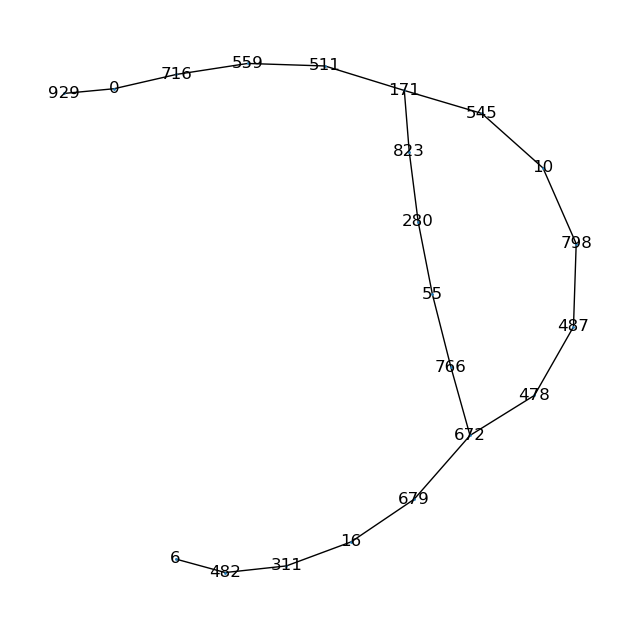

In [84]:
# Create a new NetworkX Graph() object and add all nodes and edges from the two paths shown in the cells above.
# An alternative would be to utilise a NetworkX subgraph containing the nodes and edges from the two paths
SG = nx.Graph()

for k, n in enumerate(example_shortest_paths[0][:-1]):
    SG.add_edge(n, example_shortest_paths[0][k+1])

for k, n in enumerate(example_shortest_weighted_paths[0][:-1]):
    SG.add_edge(n, example_shortest_weighted_paths[0][k+1])

fig3, ax3 = plt.subplots(figsize=(8,8))
nx.draw(SG, ax=ax3, pos=nx.spring_layout(SG, seed=1), node_size=1, with_labels = True) 
plt.show()

Here we can see that:

- The start and ends of the route are the same;
- With the cost mostly effecting which roads are taken in the middle of the route.

However, we don't yet know the extent that the edge "cost" effects routes more generally across the network - i.e., whether this is an isolated case or something that effects paths between all pairs of nodes.

<br>
<br>

#### Observing the effects at scale

The choice of appropriate methods for examining the effects of edge weights/costs across a network will depend on the specific questions you want to answer. Here we will explore two methods for summarising and visualising the difference that the edge weights/"costs" will have on "shortest" (or "lightest) path/route calculation.

Firstly, we can examine the difference in path lengths between the shortest paths between all pairs or nodes and the "lightest" paths to help to contextualise the extent that taking the "lightest" path over the shortest path as the journey route will result in lengthy diversions.

NetworkX provides a plethora of APIs for analysing paths (e.g., https://networkx.org/documentation/stable/reference/algorithms/shortest_paths.html). Here we will use all_pairs_dijkstra_path() given its speed and simplicity for the task: https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.weighted.all_pairs_dijkstra_path.html

In [90]:
# Calculate (a) shortest path between all pairs of nodes in the network.
all_sp = dict(nx.all_pairs_dijkstra_path(G)) # Change the returned Python Generator object to a dictionary

# Calculate (a) shortest, "lightest" path between all pairs of nodes in the network considering our cost weight on the edges.
all_wsp = dict(nx.all_pairs_dijkstra_path(G, weight="cost")) # Change the returned Python Generator object to a dictionary

<br>

Lets first print the path from the same example nodes used earlier in the notebook:

In [92]:
print(all_sp[from_node][to_node])
print(" ")
print(all_wsp[from_node][to_node])

['6', '482', '311', '16', '679', '672', '766', '55', '280', '823', '171', '511', '559', '716', '0', '929']
 
['6', '482', '311', '16', '679', '672', '478', '487', '798', '10', '545', '171', '511', '559', '716', '0', '929']


<br>
<br>

From here we can calculate the difference between the shortest, "lightest" path and just the shortest path between all pairs of nodes and therefore all possible starting points and destinations in the network.

In [95]:
# Get all nodes in the the network as a list
nodes = list(G.nodes())

# Generate every combination of pairs of nodes from this list using Python's itertools library
node_pairs = list(itertools.combinations(nodes, 2))

# For each pair of nodes, calculate the difference between the length of the shortest, "lightest" 
# path and the shortest path that does not considering weight/cost)
node_pair_diff = []
for pair in node_pairs:
    node_pair_diff.append(len(all_wsp[pair[0]][pair[1]]) - len(all_sp[pair[0]][pair[1]]))


<br>

We can then use this calculate some descriptive statistics to summarise the extent that path lengths change when considering weight/cost.

In [97]:
print("\nDescriptive Statistics:\n")

print(f"Mean change in path length: {np.mean(node_pair_diff):.2f}")
print(f"Std. deviation: {np.std(node_pair_diff):.2f}")
print(f"Range Min: {np.amin(node_pair_diff)} to Max: {np.amax(node_pair_diff)}")
print(f"Median change in path length: {np.median(node_pair_diff)}")


Descriptive Statistics:

Mean change in path length: 0.92
Std. deviation: 1.45
Range Min: 0 to Max: 12
Median change in path length: 0.0


<br>

Here we can see that:

- Considering the weight/cost on the edges adds an additional edge (road) to routes between nodes on average;
- However this is highly variable considering the median and range, with some not changing at all and others having a large number of additional edges.

>**Extra**: Plot the distribution of the node_pair_diff and observe how many pairs the difference in path is one or greater. 

<br>
<br>

##### (Edge) Centrality

An alternative approach could be to explore how the cost weighting effects which edges get used more in paths/routes across the network.

To do this we can utilise the concept of "centrality" in graph theory/network science which involves scoring either nodes or edges in different ways to highlight their significance/importance in the network. In this example we will focus on one type of edge-based centrality - betweenness centrality - there will be more emphasis and examples on centrality, particularly node-based centrality, in later notebooks.

> **Extra**: A quick introduction to centrality in networks:
>
> [![](https://img.youtube.com/vi/NgUj8DEH5Tc/mqdefault.jpg)](https://www.youtube.com/watch?v=NgUj8DEH5Tc)
>



<br>

Formally, the Betweenness Centrality of an edge, *e*, is the sum of the fraction of all-pairs shortest paths that pass through *e*.

Why might this be interesting and appropriate here? Consider the following example network:


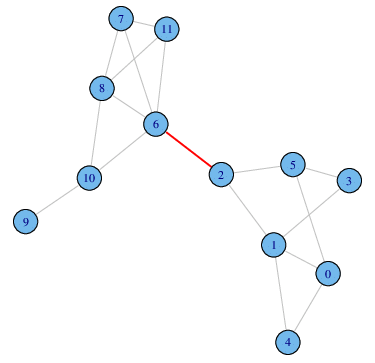 - Cuvelier and Aufaure (2012)

- Here we see that the edge between node 6 and 2 in red acts as a connector or "bridge" between two groups of nodes. 

- The edge between 6 and 2 will be contained within all calculated, shortest paths between nodes in one group (e.g., 9,10,8,7,11,6) and the other (5,4,1,0,4,2).

- This is not the case for other edges in the network (e.g., between 10 and 6, 2 and 5) therefore the edge between 6 and 2 could be seen as more "central" or "important" for enabling paths across the network in comparison to other edges. 

<br>

The NetworkX betweeness centrality APIs allow a convenient way for these centrality "scores" (between 0 and 1) to be calculated for each edge (or node): https://networkx.org/documentation/stable/reference/algorithms/centrality.html#shortest-path-betweenness

In [108]:
edge_betweenness_centrality = nx.edge_betweenness_centrality(G)

Edge weights/costs are considered by including a weight parameter in the method call:

In [110]:
weighted_edge_betweenness_centrality = nx.edge_betweenness_centrality(G, weight="cost")

<br> 

The effects of edge weight/cost on the betweenness centrality score of edges can be seen in the following examples:

In [112]:
print(f"Edge betweenness centrality for the edge between nodes 171 and 545: {edge_betweenness_centrality[('171', '545')]:.2f}")
print(f"Edge betweenness centrality for the edge between nodes 648 and 723: {edge_betweenness_centrality[('648', '723')]:.2f}")

Edge betweenness centrality for the edge between nodes 171 and 545: 0.01
Edge betweenness centrality for the edge between nodes 648 and 723: 0.26


In [113]:
print(f"Edge betweenness centrality for the edge between nodes 171 and 545: {weighted_edge_betweenness_centrality[('171', '545')]:.2f}")
print(f"Edge betweenness centrality for the edge between nodes 648 and 723: {weighted_edge_betweenness_centrality[('648', '723')]:.2f}")

Edge betweenness centrality for the edge between nodes 171 and 545: 0.05
Edge betweenness centrality for the edge between nodes 648 and 723: 0.15


These two examples highlight that the centrality score for an edge can go up when the weight/cost is considered or go down. As a result, the presence of a particular edge/road can change significantly in paths/routes across the network.

<br>
<br>

It is important to note that **a high edge betweeenness centrality score does not necessarily correlate with a low edge "cost"**. It may be that despite its high "cost", a high-"cost" edge is still considered the best option to include in paths to produce the "lightest" path overall (thus, increasing its centrality) in comparison to adding multiple alternative edges to the path.

<br>
<br>

We can also visualise the impact of considering edge weight/cost on edge centrality scores: 

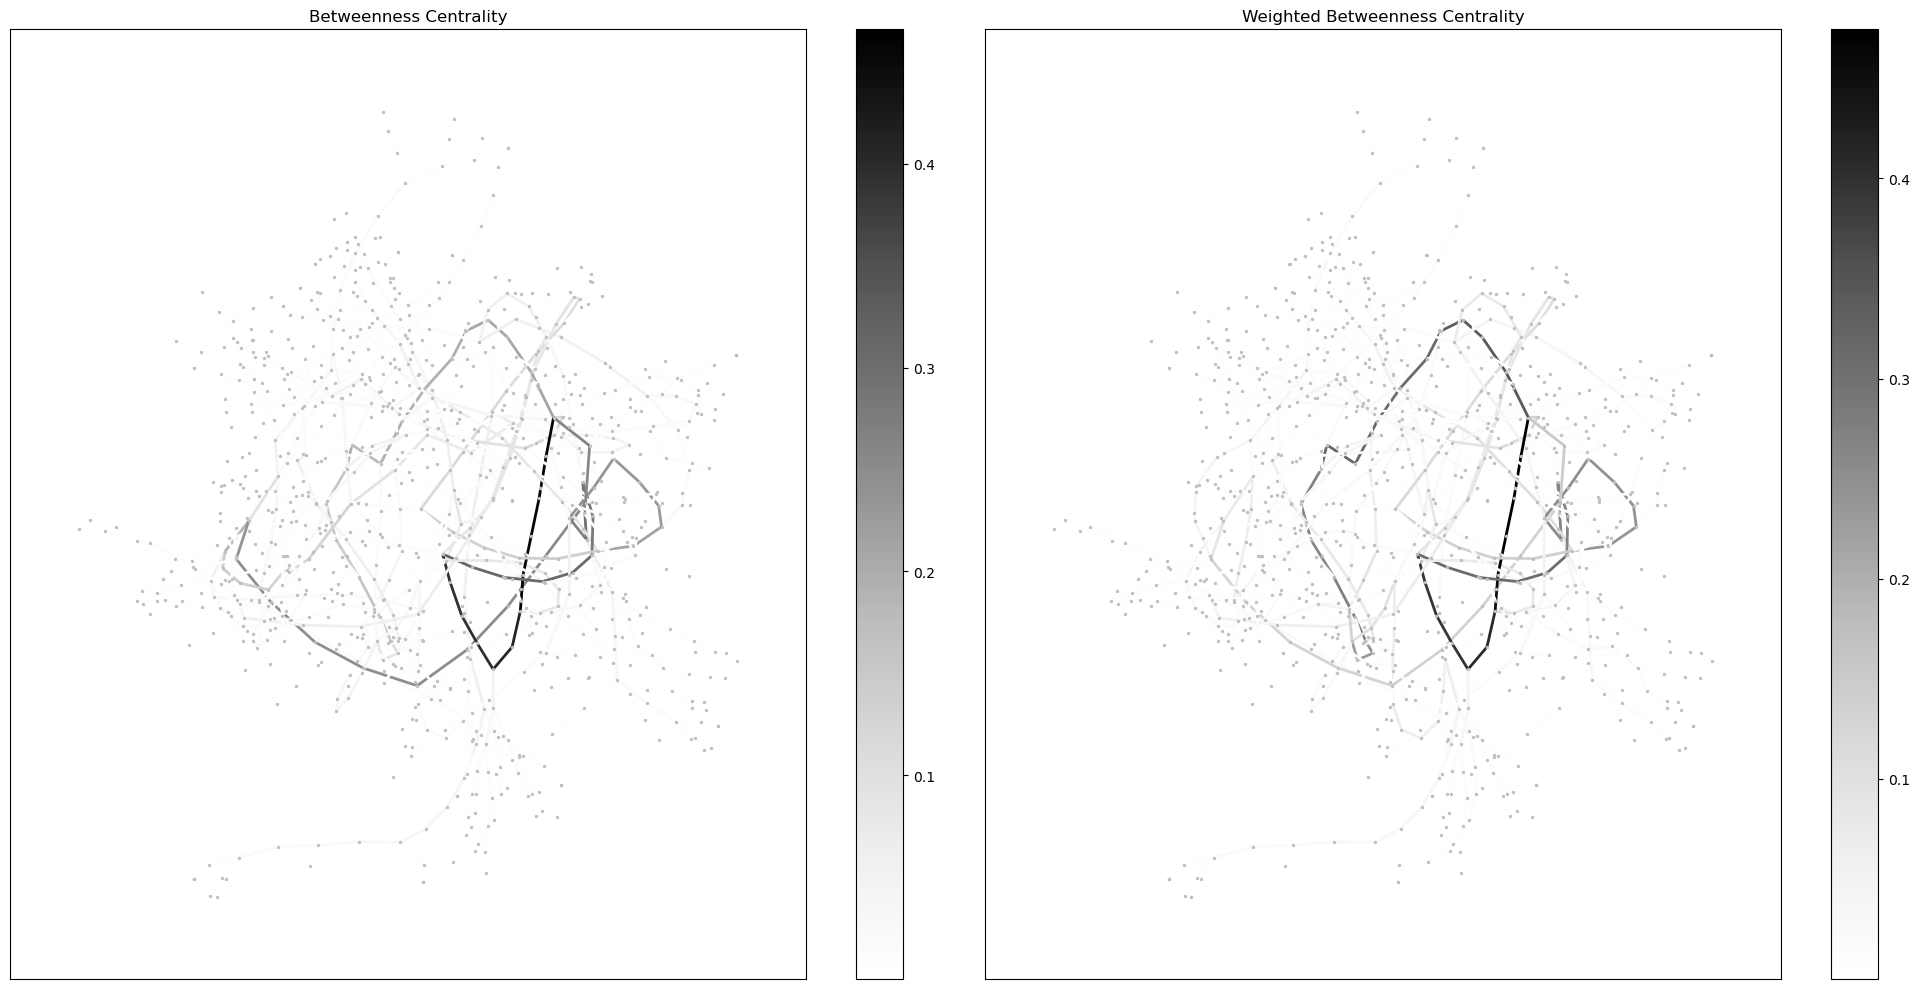

In [116]:
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(20, 10)) #create a plot containing two subplots/axs (1 row, 2 columns)

pos = nx.spring_layout(G, seed=100, k=0.01)

nx.draw_networkx_nodes(G, ax=ax1, pos=pos, node_size=2, node_color="silver")
edges = nx.draw_networkx_edges(G, pos, ax=ax1, width=2, edge_cmap=plt.cm.Greys, edge_color=list(edge_betweenness_centrality.values()), edgelist=edge_betweenness_centrality.keys())
ax1.set_title('Betweenness Centrality')
plt.colorbar(edges)

nx.draw_networkx_nodes(G, ax=ax2, pos=pos, node_size=2, node_color="silver")
w_edges = nx.draw_networkx_edges(G, pos, ax=ax2, width=2, edge_cmap=plt.cm.Greys, edge_color=list(weighted_edge_betweenness_centrality.values()), edgelist=weighted_edge_betweenness_centrality.keys())
ax2.set_title('Weighted Betweenness Centrality')
plt.colorbar(w_edges)

plt.tight_layout()

plt.show()

Darker greys indicate higher betweenness centrality (or weighted betweenness centrality) scores.

Some observations:

- Edge color/shade changes highlight some roads (edges) are now being avoided in paths due to the high "cost" weight;

- Some edges do not change very much (e.g, edges on the periphery of the network), whereas others do - particularly towards the center of the visualisation. 

<br>

**Extra**: Plotting the difference highlights the effects of the weights/costs on the edges further. 

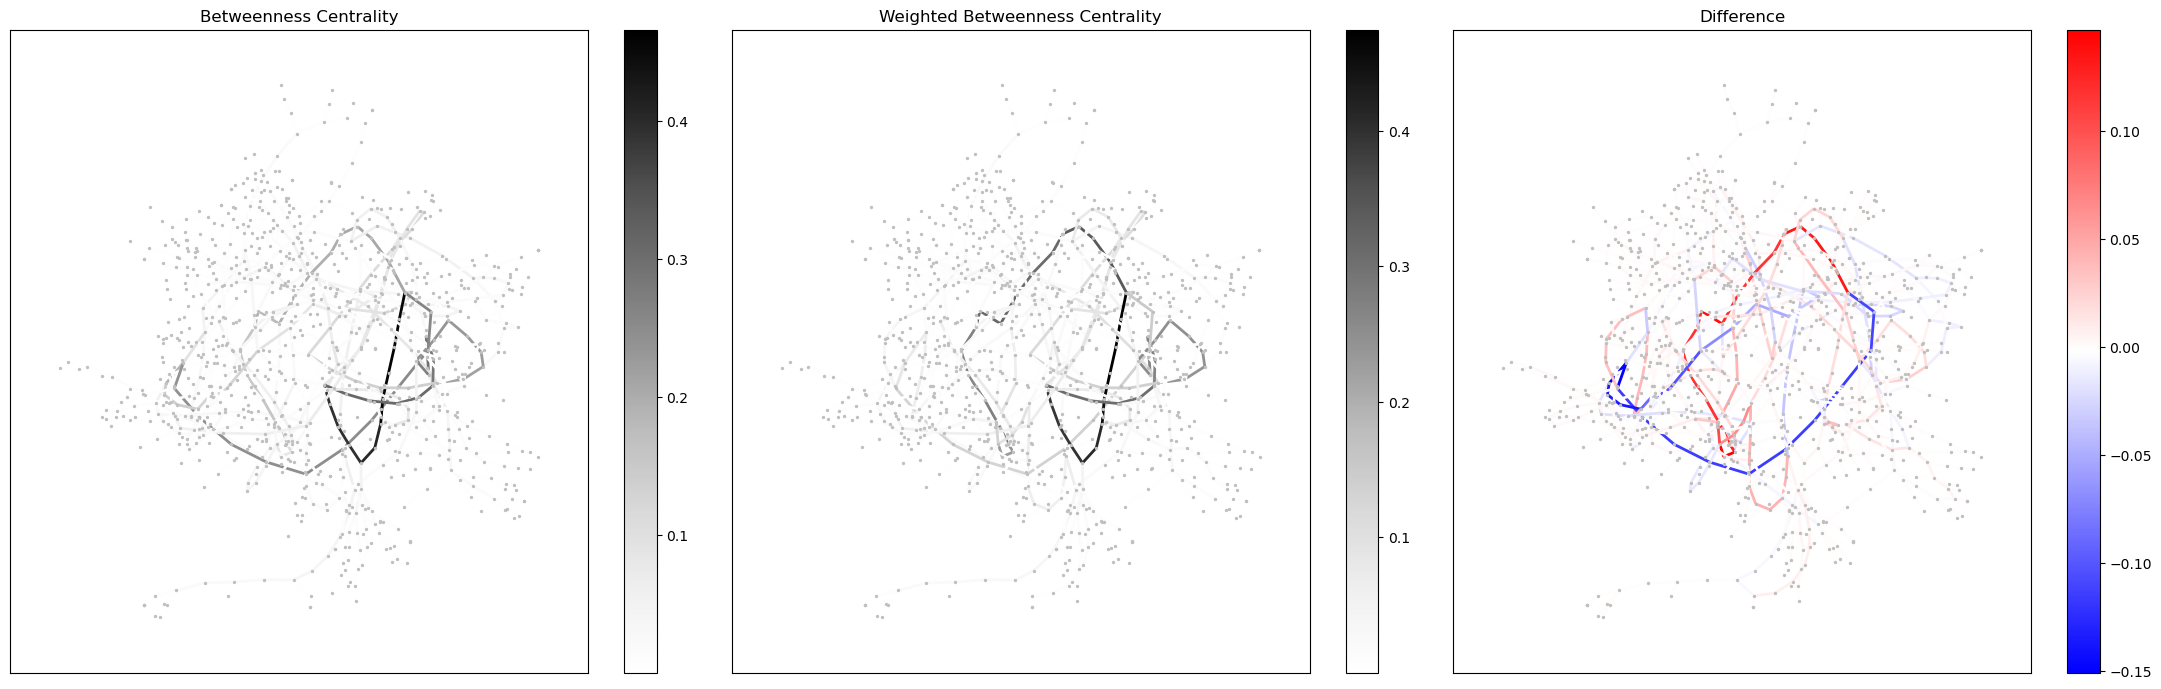

In [119]:
fig, ((ax1, ax2, ax3)) = plt.subplots(1, 3, figsize=(22, 7)) #create a plot containing two subplots/axs (1 row, 2 columns)

nx.draw_networkx_nodes(G, ax=ax1, pos=pos, node_size=2, node_color="silver")
edges = nx.draw_networkx_edges(G, pos, ax=ax1, width=2, edge_cmap=plt.cm.Greys, edge_color=list(edge_betweenness_centrality.values()), edgelist=edge_betweenness_centrality.keys())
ax1.set_title('Betweenness Centrality')
plt.colorbar(edges)

nx.draw_networkx_nodes(G, ax=ax2, pos=pos, node_size=2, node_color="silver")
w_edges = nx.draw_networkx_edges(G, pos, ax=ax2, width=2, edge_cmap=plt.cm.Greys, edge_color=list(weighted_edge_betweenness_centrality.values()), edgelist=weighted_edge_betweenness_centrality.keys())
ax2.set_title('Weighted Betweenness Centrality')
plt.colorbar(w_edges)

diff = {k: (weighted_edge_betweenness_centrality[k]-edge_betweenness_centrality[k]) for k in G.edges()}
nx.draw_networkx_nodes(G, ax=ax3, pos=pos, node_size=2, node_color="silver")
d_edges = nx.draw_networkx_edges(G, pos, ax=ax3, width=2, edge_cmap=plt.cm.bwr, edge_color=list(diff.values()), edgelist=diff.keys())
ax3.set_title('Difference')
plt.colorbar(d_edges)

plt.tight_layout()

plt.show()

<br>
<br>

**Where do we go from here?**

The investigations so far have highlighted the notable effects that the increment-based scoring approach for edges to produce edge "costs"/weights can have on potential routing applications built on top of this.

At this stage we have a few options, including:

 1. Design alternative methods to calculate the road costs and observe their effects on the paths/routes produced.
 2. Implementing additional measures/visualisations to help further observe the effects of the road costs.

<br>

These should be explored as part of independent study, where the "Extra" cells below can act as a starting point for options 1 and 2.

<br>
<br>

---

<br>
<br>

## 4. Summary and motivations going forward

1. From the case study we've seen how considering edge weights (or "costs" as used here) can have notable effects on the "shortest" paths across network structures. As part of this, we have developed some of the foundations for a routing application that could consider subjective preferences of roads beyond just the length of a path/route.

2. While simulated "crowdsourced" data has been used, it highlights key considerations for those utilising crowdsourced data more generally, particularly surrounding annotator agreement and the behaviour of individual annotators. Importantly, while scrutinising the data is useful for data quality checks/cleaning, it should also be used as a basis to scrutinise the effectiveness of the original crowdsourced task (e.g., were the instructions clear?).


**Along the way we have:**

- Combined and applied the knowledge of network theory and human computation from previous weeks in creating the foundation for a routing application.

- We've looked at more methods from graph theory surrounding centrality measures, which we will see again in later weeks. Equally centrality methods can be applied to the analysis notebooks from previous weeks (i.e., surrounding the Twitch, Reddit, and GitHub data).



<br>
<br>

---

<br>
<br>

## Extra: Exploring alternative ranking strategies

> There are numerous ways in which the cost calculation for roads (edges) can be undertaken nad you are encouraged to explore different ways of doing so. One example extension to the existing calculation method is to account for annotator disagreement.
>
>We could extend the cost calculation for edges in Example Method 1 to decrease the cost of an annotators preferred edge (road) in addition to the existing implementation of increasing the cost of the annotator's not preferred edge (road).
>
>#### Example Method 2: Incrementing and decrementing costs using annotator choices

In [128]:
# Method 2: 

nx.set_edge_attributes(G, 1, "cost2") #Calculate a second cost attribute to allow for direct comparison between this and the previous costs from earlier in the notebook

with open('annotations.csv', 'r') as file:
    reader = csv.reader(file)
    
    next(reader, None)
    
    for row in reader:
        edge_choice_A = row[1] # Some road, Road A
        edge_choice_B = row[2] # Some other road, Road B
        
        chosen_edge = row[3] # Either Road A or Road B that the "annotator" chose
        
        # Select the edge that the annotator DID NOT choose
        edge_to_increase_score_of = edge_choice_A if chosen_edge == edge_choice_B else edge_choice_B
        # Split the string representation of the edge into a list - e.g., 70-77 becomes ["70","77"]
        edge_to_increase_score_of = edge_to_increase_score_of.split("-")
        # Increment the cost for the edge - e.g. G["70"]["77"]["cost2"] += 1
        G[edge_to_increase_score_of[0]][edge_to_increase_score_of[1]]["cost2"] += 1
        

        # Extend Example Method 1 to also decrement the cost for the edge the annotator DID choose
        # However, edge weights for path-based analysis need to positive for NetworkX's APIs therefore only decrement the cost if it is greater than 1
        edge_to_decrease_score_of = chosen_edge.split("-")
        if G[edge_to_decrease_score_of[0]][edge_to_decrease_score_of[1]]["cost2"] > 1:
            G[edge_to_decrease_score_of[0]][edge_to_decrease_score_of[1]]["cost2"] -= 1

         
        
        

> The values for the "cost" attribute from Example Method 1 and "cost2" from Example Method 2 can be plotted to give some initial insight into the difference between the two calculations:

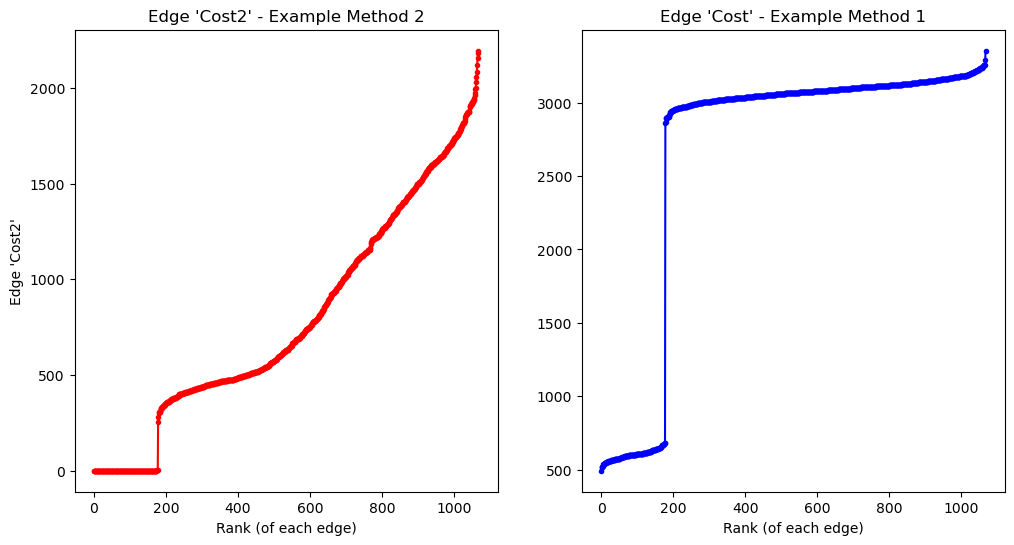

In [130]:
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(12,6)) #create a plot containing two subplots/axs (1 row, 2 columns)

edge_cost_sequence = [e[2]["cost2"] for e in G.edges(data=True)]
edge_cost_sequence = sorted(edge_cost_sequence)
ax1.plot(edge_cost_sequence, color="r", marker=".")
ax1.set_title("Edge 'Cost2' - Example Method 2")
ax1.set_ylabel("Edge 'Cost2'")
ax1.set_xlabel("Rank (of each edge)")

edge_cost_sequence = [e[2]["cost"] for e in G.edges(data=True)]
edge_cost_sequence = sorted(edge_cost_sequence)
ax2.plot(edge_cost_sequence, color="b", marker=".")
ax2.set_title("Edge 'Cost' - Example Method 1")
ax2.set_xlabel("Rank (of each edge)")

plt.show()

> Here we can see the effects of this on the distribution of costs generated. Most notably "cost2" results in smaller cost values and gives equal rankings of low costs to a small proportion of the edges/roads.
>
> We can use a combination of edge_betweenness_centrality and visualisations from earlier in this Notebook to further compare the differences between the two cost calculations

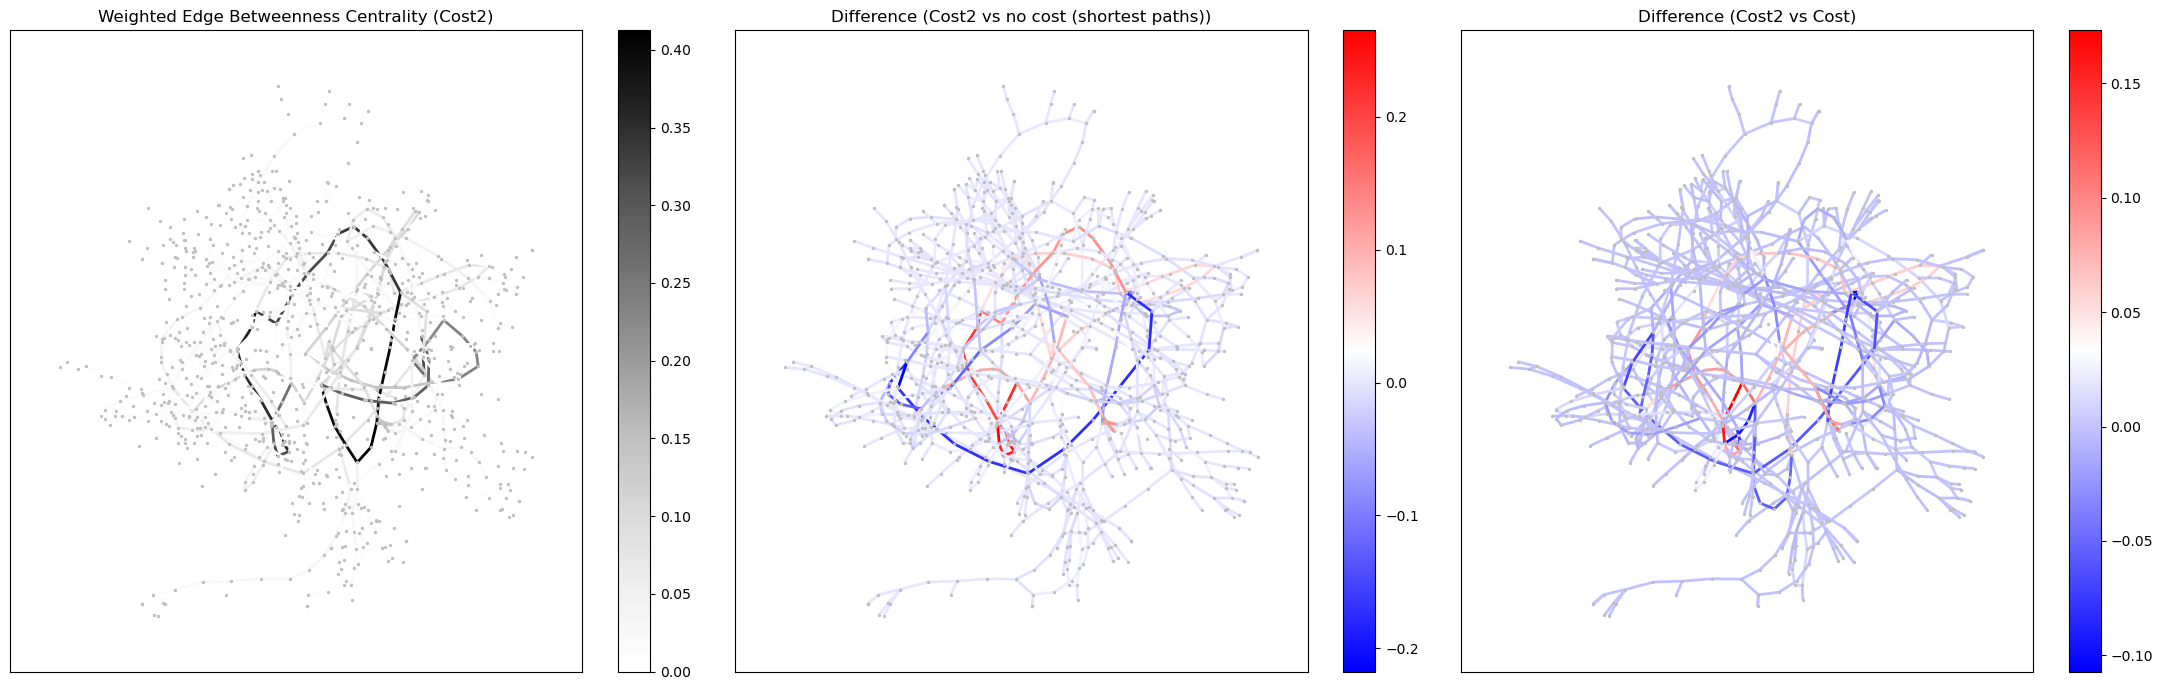

In [132]:
weighted_edge_betweenness_centrality2 = nx.edge_betweenness_centrality(G, weight="cost2")

fig, ((ax1, ax2, ax3)) = plt.subplots(1, 3, figsize=(22, 7)) #create a plot containing two subplots/axs (1 row, 2 columns)

nx.draw_networkx_nodes(G, ax=ax1, pos=pos, node_size=2, node_color="silver")
w_edges = nx.draw_networkx_edges(G, pos, ax=ax1, width=2, edge_cmap=plt.cm.Greys, edge_color=list(weighted_edge_betweenness_centrality2.values()), edgelist=weighted_edge_betweenness_centrality2.keys())
ax1.set_title('Weighted Edge Betweenness Centrality (Cost2)')
plt.colorbar(w_edges)

diff = {k: (weighted_edge_betweenness_centrality2[k]-edge_betweenness_centrality[k]) for k in G.edges()}
nx.draw_networkx_nodes(G, ax=ax2, pos=pos, node_size=2, node_color="silver")
d_edges = nx.draw_networkx_edges(G, pos, ax=ax2, width=2, edge_cmap=plt.cm.bwr, edge_color=list(diff.values()), edgelist=diff.keys())
ax2.set_title('Difference (Cost2 vs no cost (shortest paths))')
plt.colorbar(d_edges)

diff = {k: (weighted_edge_betweenness_centrality2[k]-weighted_edge_betweenness_centrality[k]) for k in G.edges()}
nx.draw_networkx_nodes(G, ax=ax3, pos=pos, node_size=2, node_color="silver")
d_edges2 = nx.draw_networkx_edges(G, pos, ax=ax3, width=2, edge_cmap=plt.cm.bwr, edge_color=list(diff.values()), edgelist=diff.keys())
ax3.set_title('Difference (Cost2 vs Cost)')
plt.colorbar(d_edges2)

plt.tight_layout()

plt.show()

> Here we can see that:
> - "cost2" similarly produces moderately high edge-centrality scores that are similarly concentrated to a part of the network.
>
> - There are some differences between the edges with the largest weighted edge betweeenness centrality between the two costs and no cost weights, and between each other, which may impact the paths/routes calculated. 
>

> **Going further**
>
> The cells above are intended to be a starting point for ideas to extend the investigations into the effects of road costs on the routing. You are encouraged to extend this further and this could involve:
> - further comparisons on the impact of the two costs further on the routes generated (e.g., refer back to the "Observing the effects at scale" section); 
> - exploring other alternatives to the two example cost calculations seen (e.g., only increase/decrease scores where some proportion/percentage of annotators agree).
